# ID5059: Flight Delays
Investigating flight delays from several airports near New York over the course of one year. Fit at least two machine learning models and prepare a summary report for the Director of Operations of a major airport. Further information on the attributes of the nycflights13 dataset can be found [here](https://openflights.org/data.php).

**Research Questions:**
1. Can we predict, before a flight has departed, whether it will arrive late?
2. Which factors are most correlated with delays?

In [293]:
# Importing the required dependencies
import numpy as np 
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler

## Creating the Test Set
Since we're working with supervised data, it would be sensible to have an even split of delays across the test and training sets. We can use arr_delay in flights.csv to create a classification label for delayed flights, combine the new flights.csv data with important-looking data from other .csv files, and then perform a train/test split before data exploration & wrangling.

1. Create a label is_delayed to classify whether a particular observation (row in flights.csv) is delayed or not
    * Are there any NA values for arr_delay? If so, what does that mean?
    * Decide whether to replace NA values or remove them
2. Check the distribution of delayed flights
3. Create analytical base table (ABT) with chosen high-level data
    * Is there any CSV data which is less useful?
4. Choose and perform test/train split
5. Verify that the % of delays in the training set matches the % of the delays in the test set

### 1. Create new classifier is_delayed

Work on a copy of the data for reproducibility.

In [294]:
# Locate the file, read it in, and observe
flights_file_name = "../data/flights.csv"
flights_data = pd.read_csv(flights_file_name)
flights_data.head()

,year,month,day,dep_time,sched_dep_time,dep_delay,arr_time,sched_arr_time,arr_delay,carrier,flight,tailnum,origin,dest,air_time,distance,hour,minute,time_hour
0,2013,1,1,517.0,515,2.0,830.0,819,11.0,UA,1545,N14228,EWR,IAH,227.0,1400,5,15,2013-01-01 05:00:00
1,2013,1,1,533.0,529,4.0,850.0,830,20.0,UA,1714,N24211,LGA,IAH,227.0,1416,5,29,2013-01-01 05:00:00
2,2013,1,1,542.0,540,2.0,923.0,850,33.0,AA,1141,N619AA,JFK,MIA,160.0,1089,5,40,2013-01-01 05:00:00
3,2013,1,1,544.0,545,-1.0,1004.0,1022,-18.0,B6,725,N804JB,JFK,BQN,183.0,1576,5,45,2013-01-01 05:00:00
4,2013,1,1,554.0,600,-6.0,812.0,837,-25.0,DL,461,N668DN,LGA,ATL,116.0,762,6,0,2013-01-01 06:00:00


In [295]:
# Check observations (shape[0]) and features (shape[1])
flights_data.shape

(336776, 19)

In [296]:
# Check for NA values
flights_data.isna().sum()

# 9430/336776 = 2.8% of the data is missing for arr_delay
# We will drop these rows since it's small enough to drop without losing too much info


year                 0
month                0
day                  0
dep_time          8255
sched_dep_time       0
dep_delay         8255
arr_time          8713
sched_arr_time       0
arr_delay         9430
carrier              0
flight               0
tailnum           2512
origin               0
dest                 0
air_time          9430
distance             0
hour                 0
minute               0
time_hour            0
dtype: int64

In [297]:
# Drop the rows where arr_delay is NA since we can't create a label from this
flights_clean = flights_data.dropna(subset=['arr_delay']).copy()
flights_delay_not_null = flights_data['arr_delay'].notnull().sum()

# Sanity check all rows with NA arr_delay have been dropped
if flights_delay_not_null == flights_clean.shape[0]:
    print(f"Rows before drop: {flights_data.shape[0]}")
    print(f"Rows dropped: {flights_data.isna().sum()['arr_delay']}")
    print(f"Rows remaining: {flights_clean.shape[0]}")

Rows before drop: 336776
Rows dropped: 9430
Rows remaining: 327346


In [298]:
# Create a binary classification label: 1 if flight is delayed (arr_delay >= 15), 0 otherwise
flights_clean['is_delayed'] = (flights_clean['arr_delay'] >= 15).astype(int)

# Sanity check is_delayed is categorising correctly
flights_clean[['arr_delay', 'is_delayed']].head(10)

,arr_delay,is_delayed
0,11.0,0
1,20.0,1
2,33.0,1
3,-18.0,0
4,-25.0,0
5,12.0,0
6,19.0,1
7,-14.0,0
8,-8.0,0
9,8.0,0


### 2. Check the distribution of delayed flights

If the dataset is imbalanced (eg 20% delays and 80% on-time) we will need to do a stratified split to ensure the train and test sets have similar proportions of delayed/on-time data.

In [299]:
# Check the proportion of delayed flights
print(flights_clean['is_delayed'].value_counts(normalize=True))

# The dataset is imbalanced (~25% flights are delayed) so we should use stratified splitting
# to ensure the proportion of delayed flights in the train / test sets are similar

is_delayed
0    0.755305
1    0.244695
Name: proportion, dtype: float64


### 3. Create ABT with chosen high-level data

Common causes of aviation delays may be the schedule (time of flight or month), the operator (airline or origin airport), or the environment (weather conditions or distance).

After inspecting the .csv files, airports.csv and planes.csv seem like they would have low additional value versus the expense of including them in the ABT. Planes could be used to see if there's a relationship between older plane machinery and flight delays, but this is not as obvious as the aforementioned assumptions (schedule, operator, and weather).

Therefore, we will use:
- **airlines.csv:** for airline name (instead of airline code which may be hard to read)
- **flights.csv:** for month, scheduled departure time, and origin airport
- **weather.csv:** for wind speed and visibility

In [300]:
# We need to merge all of flights.csv with airlines (for names) and weather (for weather info)

# Locate the weather file, read it in, and observe
weather_file_name = "../data/weather.csv"
weather_data = pd.read_csv(weather_file_name)
weather_data.head()

,origin,year,month,day,hour,temp,dewp,humid,wind_dir,wind_speed,wind_gust,precip,pressure,visib,time_hour
0,EWR,2013,1,1,1,39.02,26.06,59.37,270.0,10.35702,NaN,0.0,1012.0,10.0,2013-01-01T06:00:00Z
1,EWR,2013,1,1,2,39.02,26.96,61.63,250.0,8.05546,NaN,0.0,1012.3,10.0,2013-01-01T07:00:00Z
2,EWR,2013,1,1,3,39.02,28.04,64.43,240.0,11.50780,NaN,0.0,1012.5,10.0,2013-01-01T08:00:00Z
3,EWR,2013,1,1,4,39.92,28.04,62.21,250.0,12.65858,NaN,0.0,1012.2,10.0,2013-01-01T09:00:00Z
4,EWR,2013,1,1,5,39.02,28.04,64.43,260.0,12.65858,NaN,0.0,1011.9,10.0,2013-01-01T10:00:00Z


In [301]:
# Check the features in more detail to identify potential features to merge with flights.csv
weather_data.info()

# Origin, year, month, day, and hour have no null entries (could be primary key)

<class 'pandas.DataFrame'>
RangeIndex: 26115 entries, 0 to 26114
Data columns (total 15 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   origin      26115 non-null  str    
 1   year        26115 non-null  int64  
 2   month       26115 non-null  int64  
 3   day         26115 non-null  int64  
 4   hour        26115 non-null  int64  
 5   temp        26114 non-null  float64
 6   dewp        26114 non-null  float64
 7   humid       26114 non-null  float64
 8   wind_dir    25655 non-null  float64
 9   wind_speed  26111 non-null  float64
 10  wind_gust   5337 non-null   float64
 11  precip      26115 non-null  float64
 12  pressure    23386 non-null  float64
 13  visib       26115 non-null  float64
 14  time_hour   26115 non-null  str    
dtypes: float64(9), int64(4), str(2)
memory usage: 3.0 MB


In [302]:
# Check if the combination of origin, year, month, day, and hour is unique in weather.csv
is_unique = weather_data.groupby(['origin', 'year', 'month', 'day', 'hour']).size().max() == 1
print(f"Is the keyset unique: {is_unique}")

# It's not, so identify all rows that have a duplicate combination of our keys
keys = ['origin', 'year', 'month', 'day', 'hour']
duplicates = weather_data[weather_data.duplicated(subset=keys, keep=False)]

print(f"Number of duplicate rows: {duplicates.shape[0]} / {weather_data.shape[0]}")

# Sort them so the duplicates are next to each other
duplicates.sort_values(by=keys).head(10)

# Twice a year there are two entries for each airport at the same hour on the same day
# We will assume this is due to clocks going forward / back for daylight savings time

Is the keyset unique: False
Number of duplicate rows: 6 / 26115


,origin,year,month,day,hour,temp,dewp,humid,wind_dir,wind_speed,wind_gust,precip,pressure,visib,time_hour
7318,EWR,2013,11,3,1,51.98,39.02,61.15,310.0,6.90468,NaN,0.0,1009.8,10.0,2013-11-03T05:00:00Z
7319,EWR,2013,11,3,1,50.00,39.02,65.80,290.0,5.75390,NaN,0.0,1010.5,10.0,2013-11-03T06:00:00Z
16023,JFK,2013,11,3,1,53.96,37.94,54.51,320.0,9.20624,NaN,0.0,1009.8,10.0,2013-11-03T05:00:00Z
16024,JFK,2013,11,3,1,51.98,37.94,58.62,310.0,6.90468,NaN,0.0,1010.5,10.0,2013-11-03T06:00:00Z
24729,LGA,2013,11,3,1,55.04,39.02,54.67,330.0,9.20624,NaN,0.0,1009.3,10.0,2013-11-03T05:00:00Z
24730,LGA,2013,11,3,1,53.96,39.92,58.89,310.0,8.05546,NaN,0.0,1010.2,10.0,2013-11-03T06:00:00Z


In [303]:
# Both entries have weather info for the same time so we will calculate a simple mean of numeric values
weather_data_unique = weather_data.groupby(keys).mean(numeric_only=True).reset_index()

# Verify after taking the mean that the keyset is now unique
is_unique = weather_data_unique.groupby(['origin', 'year', 'month', 'day', 'hour']).size().max() == 1
print(f"Is the keyset unique: {is_unique}")

# Sanity check the new dataframe looks as expected
weather_data_unique.head(10)

Is the keyset unique: True


,origin,year,month,day,hour,temp,dewp,humid,wind_dir,wind_speed,wind_gust,precip,pressure,visib
0,EWR,2013,1,1,1,39.02,26.06,59.37,270.0,10.35702,NaN,0.0,1012.0,10.0
1,EWR,2013,1,1,2,39.02,26.96,61.63,250.0,8.05546,NaN,0.0,1012.3,10.0
2,EWR,2013,1,1,3,39.02,28.04,64.43,240.0,11.50780,NaN,0.0,1012.5,10.0
3,EWR,2013,1,1,4,39.92,28.04,62.21,250.0,12.65858,NaN,0.0,1012.2,10.0
4,EWR,2013,1,1,5,39.02,28.04,64.43,260.0,12.65858,NaN,0.0,1011.9,10.0
5,EWR,2013,1,1,6,37.94,28.04,67.21,240.0,11.50780,NaN,0.0,1012.4,10.0
6,EWR,2013,1,1,7,39.02,28.04,64.43,240.0,14.96014,NaN,0.0,1012.2,10.0
7,EWR,2013,1,1,8,39.92,28.04,62.21,250.0,10.35702,NaN,0.0,1012.2,10.0
8,EWR,2013,1,1,9,39.92,28.04,62.21,260.0,14.96014,NaN,0.0,1012.7,10.0
9,EWR,2013,1,1,10,41.00,28.04,59.65,260.0,13.80936,NaN,0.0,1012.4,10.0


In [305]:
# Check the features in more detail to be sure
weather_data_unique.info()

# Number of rows has reduced from 26115 to 26112 after removing duplicates (3 pairs merged)
# So this is as expected

<class 'pandas.DataFrame'>
RangeIndex: 26112 entries, 0 to 26111
Data columns (total 14 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   origin      26112 non-null  str    
 1   year        26112 non-null  int64  
 2   month       26112 non-null  int64  
 3   day         26112 non-null  int64  
 4   hour        26112 non-null  int64  
 5   temp        26111 non-null  float64
 6   dewp        26111 non-null  float64
 7   humid       26111 non-null  float64
 8   wind_dir    25652 non-null  float64
 9   wind_speed  26108 non-null  float64
 10  wind_gust   5337 non-null   float64
 11  precip      26112 non-null  float64
 12  pressure    23383 non-null  float64
 13  visib       26112 non-null  float64
dtypes: float64(9), int64(4), str(1)
memory usage: 2.8 MB


In [306]:
# Perform a left join using the chosen keys, keep all flight info but adding new weather info
flights_weather = flights_clean.merge(weather_data_unique, on=keys, how='left')

# Sanity check the merge worked as expected
flights_weather.info()

<class 'pandas.DataFrame'>
RangeIndex: 327346 entries, 0 to 327345
Data columns (total 29 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   year            327346 non-null  int64  
 1   month           327346 non-null  int64  
 2   day             327346 non-null  int64  
 3   dep_time        327346 non-null  float64
 4   sched_dep_time  327346 non-null  int64  
 5   dep_delay       327346 non-null  float64
 6   arr_time        327346 non-null  float64
 7   sched_arr_time  327346 non-null  int64  
 8   arr_delay       327346 non-null  float64
 9   carrier         327346 non-null  str    
 10  flight          327346 non-null  int64  
 11  tailnum         327346 non-null  str    
 12  origin          327346 non-null  str    
 13  dest            327346 non-null  str    
 14  air_time        327346 non-null  float64
 15  distance        327346 non-null  int64  
 16  hour            327346 non-null  int64  
 17  minute          32734

In [307]:
# Check if carrier is null in flights_weather before joining
flights_weather['carrier'].isna().sum()

np.int64(0)

In [308]:
# Locate the airlines file, read it in, and observe
airlines_file_name = "../data/airlines.csv"
airlines_data = pd.read_csv(airlines_file_name)
airlines_data.head(20)

# Airlines.csv is a complete list of all carriers and their names

,carrier,name
0,9E,Endeavor Air Inc.
1,AA,American Airlines Inc.
2,AS,Alaska Airlines Inc.
3,B6,JetBlue Airways
4,DL,Delta Air Lines Inc.
5,EV,ExpressJet Airlines Inc.
6,F9,Frontier Airlines Inc.
7,FL,AirTran Airways Corporation
8,HA,Hawaiian Airlines Inc.
9,MQ,Envoy Air


In [311]:
# Perform a left join on carrier to add airline names instead of just codes for readability of analysis
flights_weather_airlines = flights_weather.merge(airlines_data, on='carrier', how='left')

# (Briefly) Sanity check the merged dataframe is what we expect before doing any splitting
flights_weather_airlines.info()

<class 'pandas.DataFrame'>
RangeIndex: 327346 entries, 0 to 327345
Data columns (total 30 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   year            327346 non-null  int64  
 1   month           327346 non-null  int64  
 2   day             327346 non-null  int64  
 3   dep_time        327346 non-null  float64
 4   sched_dep_time  327346 non-null  int64  
 5   dep_delay       327346 non-null  float64
 6   arr_time        327346 non-null  float64
 7   sched_arr_time  327346 non-null  int64  
 8   arr_delay       327346 non-null  float64
 9   carrier         327346 non-null  str    
 10  flight          327346 non-null  int64  
 11  tailnum         327346 non-null  str    
 12  origin          327346 non-null  str    
 13  dest            327346 non-null  str    
 14  air_time        327346 non-null  float64
 15  distance        327346 non-null  int64  
 16  hour            327346 non-null  int64  
 17  minute          32734

In [289]:
flights_weather_airlines.info()

<class 'pandas.DataFrame'>
RangeIndex: 327346 entries, 0 to 327345
Data columns (total 23 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   year            327346 non-null  int64  
 1   month           327346 non-null  int64  
 2   day             327346 non-null  int64  
 3   dep_time        327346 non-null  float64
 4   sched_dep_time  327346 non-null  int64  
 5   dep_delay       327346 non-null  float64
 6   arr_time        327346 non-null  float64
 7   sched_arr_time  327346 non-null  int64  
 8   arr_delay       327346 non-null  float64
 9   carrier         327346 non-null  str    
 10  flight          327346 non-null  int64  
 11  tailnum         327346 non-null  str    
 12  origin          327346 non-null  str    
 13  dest            327346 non-null  str    
 14  air_time        327346 non-null  float64
 15  distance        327346 non-null  int64  
 16  hour            327346 non-null  int64  
 17  minute          32734

Convert column types into the correct categories 

In [290]:
# List out the columns to change type from str to category
category_columns = ["month", "carrier", "origin", "dest", "name"]

# Convert the types
flights_weather_airlines[category_columns] = flights_weather_airlines[category_columns].astype('category')

# Check the data types have been updated correctly
flights_weather_airlines.dtypes.to_frame(name='Updated Data Type')

,Updated Data Type
year,int64
month,category
day,int64
dep_time,float64
sched_dep_time,int64
dep_delay,float64
arr_time,float64
sched_arr_time,int64
arr_delay,float64
carrier,category


### 4. Perform train / test split

Bin the arr_delay minutes into a category to ensure the train and test set get an equal share of on time, slightly late and majorly

<Axes: xlabel='arr_delay', ylabel='count'>

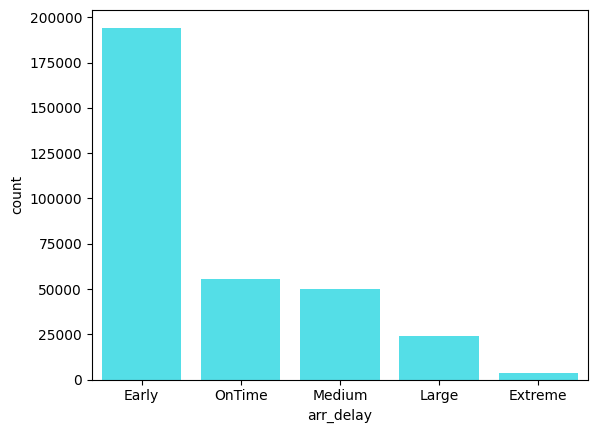

In [291]:
# Create the bins to split arr_delay into categories for stratificatoin
strat_bins = pd.cut(
    flights_weather_airlines['arr_delay'],
    bins=[-np.inf, 0, 15, 60, 180, np.inf],
    labels=['Early', 'OnTime', 'Medium', 'Large', 'Extreme']
)

# View the distribution of the bins
sns.countplot(x=strat_bins, color='#3cf3ff')

# This confirms the distribution is imbalanced so stratified sampling would be beneficial

In [292]:
# Define how to split the data
shuffled_data = StratifiedShuffleSplit(
    n_splits=1, # We are only splitting once for a train & test set
    test_size=0.2, # Test set will be 20% of the data
    random_state=42 # Set seed to maintain split and reproducibility (Geron always uses 42)
)

# Create indexes based on the 5 bins
[(train_index, test_index)] = shuffled_data.split(
    flights_weather_airlines,
    strat_bins
)

# Create the train and test sets using the indexes
# Using a copy to keep them independent
flights_train = flights_weather_airlines.iloc[train_index].copy()
flights_test = flights_weather_airlines.iloc[test_index].copy()

### 5. Verify that the Training & Test Set have similar delay distributions

  delay_category     train      test
0          Early  0.593689  0.593692
1         OnTime  0.169160  0.169161
2         Medium  0.152259  0.152253
3          Large  0.073153  0.073148
4        Extreme  0.011738  0.011746


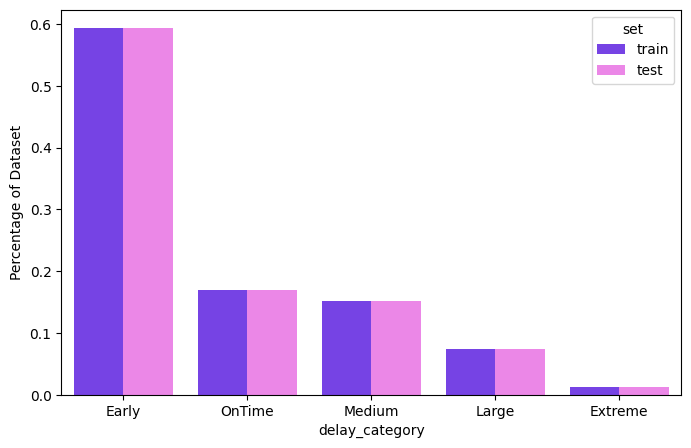

In [272]:
# Get the pre-calculated proportions using the indexes
train_dist = strat_bins.iloc[train_index].value_counts(normalize=True)
test_dist = strat_bins.iloc[test_index].value_counts(normalize=True)

# Combine and reset index in one go
dist_df = pd.DataFrame({'train': train_dist, 'test': test_dist}).reset_index()
dist_df.columns = ['delay_category', 'train', 'test']

# Check the distribution numbers
print(dist_df)

# Plot for easy viewing of train / test set distribution comparison
dist_melted = dist_df.melt(id_vars='delay_category', var_name='set', value_name='percentage')

plt.figure(figsize=(8,5))
sns.barplot(data=dist_melted, x='delay_category', y='percentage', hue='set', palette=['#6c28ff','#fc76f7'])
plt.ylabel('Percentage of Dataset')
plt.show()

## Organising the Data

From this point forward, this is on the TRAINING SET ONLY.

In [23]:
flights_shape = flights_data.shape
print(f"There are {flights_shape[0]} observations (rows) and {flights_shape[1]} features (columns) in flights.csv")

There are 336776 observations (rows) and 19 features (columns) in flights.csv


### Checking data types

In [18]:
# Converted output to a dataframe for better readability
flights_data.dtypes.to_frame(name='Data Type')

,Data Type
year,int64
month,int64
day,int64
dep_time,str
sched_dep_time,int64
dep_delay,str
arr_time,str
sched_arr_time,int64
arr_delay,str
carrier,str


Convert column types in the data to the correct types if they are not what you'd expect.

In [7]:
# List out the columns which are categories to change their type from str to category
category_columns = ["currency", "fee", "has_photo", "price_type", "source"]

# Convert the category columns to the 'category' data type in one go
data[category_columns] = data[category_columns].astype('category')

data.dtypes.to_frame(name='Updated data Type')

,Updated data Type
id,int64
category,str
title,str
body,str
amenities,str
bathrooms,float64
bedrooms,int64
currency,category
fee,category
has_photo,category


#### Missing Values

Check for missing values 

In [9]:
# data.isna() returns a 1 (true) or 0 (false) for each value in the dataframe
# depending on whether it is null or not

# the sum function takes axis=0 or axis=1
# axis=0 sums down the columns (ie gives the total number of missing values in each column)
# axis=1 sums across the rows (ie gives the total number of missing values in each row)

# to_frame is only used for visual purposes (not essential)
data.isna().sum(axis=0).to_frame(name='# Missing values')

,# Missing values
id,0
category,0
title,0
body,0
amenities,357
bathrooms,2
bedrooms,0
currency,0
fee,0
has_photo,0


* Which rows would you drop?
* Which features would you drop?
* Would you replace data for any features?

## Data Exploration

### Consider the attributes

For each feature we need to know

* Name, description, what does it mean?
* Type, categorical (ordered?), numerical (int/float), text etc.
* Missing values.
* Noisiness and type of noise.
* Usefulness.
* Distribution
* Is it a unique identifier?

You can find some of this information on the webpage. The name is often different to the column heading, the column heading is easily usable in code, the name easily understandable by humans. You would typically use the name to label graphs or tables that are output for people other than yourself to read. Information about the variables might also give you an idea of usefulness. 

#### Look for unique identifiers

How many different values are there for each each column, 
this can help identifier unique identifiers which we may want to exclude.
If it is a unique identifier, is there any data encoded within the identifier 
that might be useful, e.g. date, order, location.

## Data Wrangling

Read the [variable information](https://openflights.org/data.php) on the website and look at the data in the columns to get an understanding of what each variable represents.

### Prepare the data
1. Keep the original data intact
2. Use functions to transform the data

### Data cleaning
1. Outliers (fix / remove)
2. Missing data (drop observations / drop features / fill in values)
3. Feature selection
4. Feature engineering
- Discretise continuous features
- Decompose text, categories
- Transform numerical
- Aggregate
5. Feature scaling (center / standardise / normalise)

In [19]:
data.nunique().to_frame("# of unique values")

# From this we can see that id and body have the same number of unique 
# values as there are rows in the data and title has nearly the same.
# These are unique identifiers.
# Many of the numeric columns also have nearly unique values
# this doesn't indicate they are unique identifiers

,# of unique values
id,1000
category,1
title,978
body,1000
amenities,400
bathrooms,9
bedrooms,7
currency,1
fee,1
has_photo,3


### Distribution

For each feature plot the distribution.

#### Continuous features

Ask your self what sort of distribution is it?

* uniform,
* symmetrical about a centre point, 
* an initial peak then falls?
* is it a narrow or wide spread of data? 
* Are there lots of outliers? 
* Is it bounded, e.g. all values are above 0, or within a certain range?

Does it fall into obvious groups, might it be better to split this data into categories instead?

Would you replace missing data with mean or median. 

In [ ]:
# The long tails indicate it would be better to replace missing values with median 
# rather than mean. The median will be closer to the bulk of the data, 
# the mean will be further into the tail
# maybe it would be best to replace bed and bathrooms with most common values

#### Categorical features

* Are the categories approximately balanced, 
* or are there many more of some categories.

Bathrooms and bedrooms could be plotted as either numeric or as categories

Based on your exploration so far how would you deal with the missing data?

In [ ]:
# You could drop the columns with only one value
# You could replace with the most common values
# For pets allowed and photo, 
# it might be best to use the No or None as the obvious default.

### Order

Sometimes datasets are saved in a particular order. 
It is a good idea to plot features against order in the dataset to see if this is the case. Often we want data arranged randomly, so it is important to know if there is an underlying order.

In [ ]:
# There is no obvious pattern compared to the order of the data for price
sns.scatterplot(x=list(range(1000)), y=data['price'])
# You should also check the other variables

### Look for relationships with response

Plot each attribute against the response, 
this will give you an idea if there is any pattern or relationship 
between the variable and the response.

#### Continuous vs Continuous

* Is there any pattern in the data?
  - Is it strong or weak
  - Is the pattern linear or non linear
  - Is it positive or negative

In [ ]:
# REPEAT FOR EVERY NUMERICAL VARIABLE
# Numerical variables:
# price, square_feet, latitude, longitude, time

sns.scatterplot(x=data['square_feet'], y=data['price'])
# price vs square feet has a strong, linear, positive relationship
# but it is noisy

Geographical plot

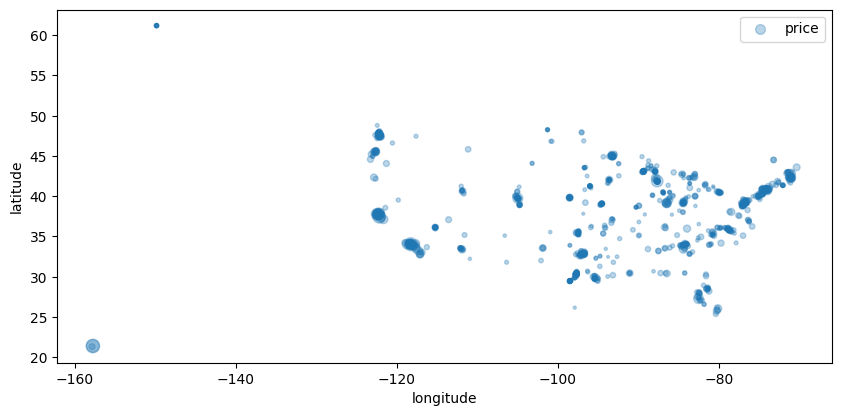

In [53]:
plot = data.plot(kind="scatter", 
    x="longitude", y="latitude", alpha=0.3,
    s=data["price"]/100,
    label="price", figsize=(10,7), sharex=False)
plot.set_aspect('equal')

#### Continuous vs Feature

* Is there a difference between groups
  - look at centre?
  - look at range?

<Axes: xlabel='bedrooms', ylabel='price'>

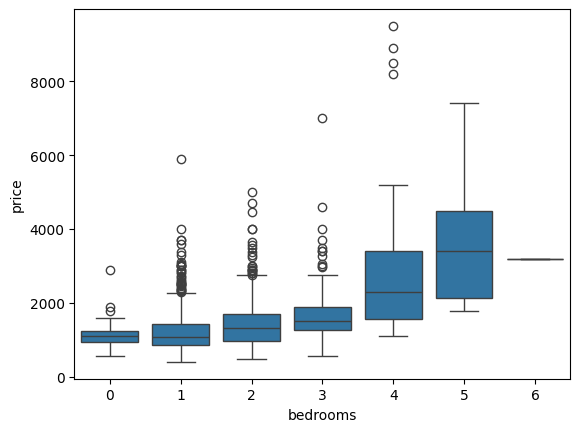

In [54]:
sns.boxplot(x=data['bedrooms'], y=data['price'])
# clear rising trend

### Look for relationships with other variables

Plot each feature against other features. If there is a very strong relationship between two features you may choose to exclude one or the other from the model.

<Axes: xlabel='latitude', ylabel='square_feet'>

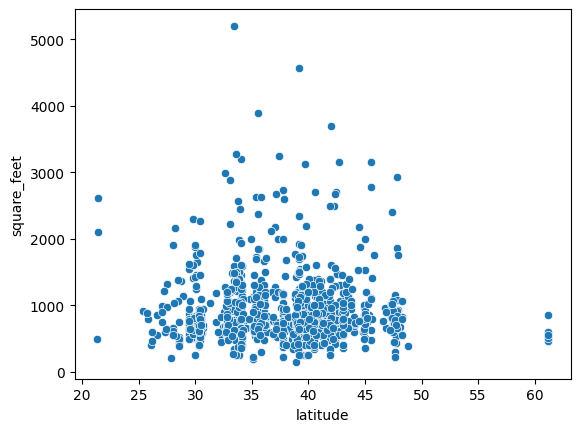

In [60]:
# Maybe some pattern in latitude less visible in longitude
sns.scatterplot(x=data['latitude'], y=data['square_feet'])

#### Feature vs Feature

Does a category occur more often with some categories than others

In [66]:
# some relationship between no of bedrooms and bathrooms
pd.crosstab(data['bedrooms'], data['bathrooms'])
# check other factor variables in same manner

bathrooms,1.0,1.5,2.0,2.5,3.0,3.5,4.0,4.5,5.0
bedrooms,,,,,,,,,
0,19,0,0,0,0,0,0,0,0
1,496,4,1,0,0,0,0,0,0
2,144,25,135,9,1,0,0,0,0
3,22,3,65,7,12,1,1,0,0
4,2,0,19,5,7,3,5,0,0
5,1,1,2,1,2,2,0,2,0
6,0,0,0,0,0,0,0,0,1


### Check correlations

In [77]:
correlations = data.corr(numeric_only=True)
correlations

,id,bathrooms,bedrooms,price,square_feet,latitude,longitude,time
id,1.000000,-0.031630,0.054328,0.012756,0.025767,-0.078466,-0.191686,0.999826
bathrooms,-0.031630,1.000000,0.733833,0.509812,0.799611,-0.061404,-0.031226,-0.032924
bedrooms,0.054328,0.733833,1.000000,0.419315,0.761180,-0.013428,0.019321,0.052862
price,0.012756,0.509812,0.419315,1.000000,0.510787,0.003370,-0.257913,0.012151
square_feet,0.025767,0.799611,0.761180,0.510787,1.000000,0.010508,0.003751,0.024142
latitude,-0.078466,-0.061404,-0.013428,0.003370,0.010508,1.000000,-0.112729,-0.079477
longitude,-0.191686,-0.031226,0.019321,-0.257913,0.003751,-0.112729,1.000000,-0.192771
time,0.999826,-0.032924,0.052862,0.012151,0.024142,-0.079477,-0.192771,1.000000


## More data cleaning

Now we have learned more about the data we can make some more decisions about the best ways to clean the data.

### Deal with the missing data

* Remove rows with lots of missing data
* Remove columns with lots of missing data
* Fill in values for remaining missing data

In [ ]:
data['pets_allowed'].unique()

In [ ]:
# drop rows that have lots of missing data, doesn't apply in this case

# drop columns that have only one value
data = data.drop(columns=["currency", "fee", "price_type"])

# We probably want to keep both the rows and columns but need to fill in the data
# Lets use None as the default for pets allowed if data missing
data['pets_allowed'] = np.where(data['pets_allowed'].isnull, 
                          "None", data['pets_allowed'])

# For bathrooms lets replace with most common value 1
data['bathrooms'] = np.where(data['bathrooms'], 1.0, data['bathrooms'])

# For the small number of city, state missing data 
# we could find the missing info from the body.
# City and state are likely to have large effects,
# imputing the mode only has a 1 in 50 chance of being right for the state
# and even less for the city

# It might be easier to just drop the missing rows in this case
data = data[data['state'].notnull()]

## Feature selection

Based on your exploration above if you could only select 5 features what would they be?
Similarly what features would you be most likely to drop from the model?

In [ ]:
# Feature selection is more art than science. 
# I would keep: bedrooms, bathrooms, square_feet, state, pets allowed

# Looking at the correlations: 
# bedroom, bathroom and square feet have the largest correlation with price
# this would be a good reason for keeping them

# There is a clear geographic pattern 
# latitude, longitude and state all showing non linear patterns, 
# city has too many unique values to deal with easily.
# I would either include, state, or city or lat & long, 
# but not more than one of these as they are strongly related.

# Perhaps this is an indication that some form of featue engineering is needed 
# to deal with the geographical pattern. 
# The simplest method would be to include state as a geographical variable

# We have already dropped anything that only has one value
# I would also drop ID, title and body as unique values
# I would also drop image or not as there did not seem to be much pattern. 

columns_to_keep = ["bedrooms", "bathrooms", "square_feet", "state", "pets_allowed", "price", "cityname"]
data = data[columns_to_keep]


## Feature Engineering

How would you engineer new features from the data?

### Convert numeric to categories

Are there any numeric variables you would convert to categories?

In [ ]:
# You could set bedrooms as a category
# Maybe convert bathrooms rounding 0.5 values to integers
# You might decide to do convert square feet into small, med, large, xlarge or other ranges
# Maybe you would choose to do some or none of these.
# I'm going to leave them as numeric rather than categories

### Consider spliting codes / dates

Think of ways you might split the factor variables that could be more useful?

In [ ]:
# Split pets allowed into 2 columns cats allowed, dogs allowed
data['cats_allowed'] = np.logical_or(data['pets_allowed'] == 'Cats', data['pets_allowed'] == 'Cats,Dogs')
data['dogs_allowed'] = np.logical_or(data['pets_allowed'] == 'Dogs', data['pets_allowed'] == 'Cats,Dogs')
data = data.drop(columns=['pets_allowed'])

# Maybe split states into larger groups, e.g regions
# https://en.wikipedia.org/wiki/List_of_regions_of_the_United_States
# This reduces the number of factors when we convert to one hot encoding
D1 = ["CT", "ME", "MA", "NH", "RI", "VT"]
D2 = ["NJ", "NY", "PA"]
D3 = ["IL", "IN", "MI", "OH", "WI"]
D4 = ["IA", "KS", "MN", "MO", "NE", "ND", "SD"]
D5 = ["DE", "FL", "GA", "MD", "NC", "SC", "VA", "DC", "WV"]
D6 = ["AL", "KY", "MS", "TN"]
D7 = ["AR", "LA", "OK", "TX"]
D8 = ["AZ", "CO", "ID", "MT", "NV", "NM", "UT", "WY"]
D9 = ["AK", "CA", "HI", "OR", "WA"]

conditions = [
    (data["state"].isin(D1)),
    (data["state"].isin(D2)),
    (data["state"].isin(D3)),
    (data["state"].isin(D4)),
    (data["state"].isin(D5)),
    (data["state"].isin(D6)),
    (data["state"].isin(D7)),
    (data["state"].isin(D8)),
    (data["state"].isin(D9)),
]
choices = ["New_England","Mid_Atlantic","E_N_Central","W_N_Central","South_Atlantic",
           "E_S_Central","W_S_Central","Mountain","Pacific"]
data['region'] =  np.select(conditions, choices)
data['region'] = pd.Categorical(data['region'])
data = data.drop(columns="state")

# We know from experience that rents in some places are more expensive than others
# These variations are more likely to be on the city scale than states or regions 
# so maybe we need to add this city into the model.
# city has too many factors to easily deal with.
# As an alternative we  could group cities into high, medium, low price cities

# calculate mean price for each city
cities = data.groupby(['cityname'])[['price']].mean()
# view distribution of means
print(sns.histplot(cities.price))

# make a judgement of where to split into low medium high price cities
high_cities = cities[cities['price']>2000].index
low_cities = cities[cities['price']<1000].index

# I'm going to say below <1000 is low and >2000 is high, 
# you could use any other split you think is a good idea
city_conditions = [
    (data['cityname'].isin(high_cities)),
    (data['cityname'].isin(low_cities)),
]
city_choices = ["high", "low"]
data['cityprice'] = np.select(city_conditions, city_choices, default="med")
data['cityprice'] = pd.Categorical(data['cityprice'])
data = data.drop(columns="cityname")

# Note there are many other sensible ways to approach this, 
# you can use your knowledge of renting housing 
# and what you see if the data to justify your decisions.

### Text 

Is there any useful information that can be extracted?

In [ ]:
# Looking at the text in the body column there is a lot of information 
# there that isn't otherwise captured, for example commuting information. 
# It's likely to be complicated to extract though. 
# So you would have to choose if the time spent trying is worth it. 
#
# The amenities column also looks useful and this might be easier to split up. 
# This is an interesting challenge to consider if you have quickly completed the rest of this practical

### Convert remaining factors to one_hot


In [ ]:
# define encoder
one_hot_encoder = OneHotEncoder(sparse_output=False)
one_hot_encoder.set_output(transform="pandas")

categorical_attributes = ['region', 'cityprice']
data_categorical_encoded = pd.DataFrame(one_hot_encoder.fit_transform(data[categorical_attributes]))

data = pd.concat((data, data_categorical_encoded), axis=1)

### Scale numeric factors

In [ ]:
scaler = StandardScaler()

numerical_attributes = ["bathrooms", "bedrooms", "square_feet"]

data_num = scaler.fit_transform(data[numerical_attributes])

# convert to pandas data frame object.
data_num = pd.DataFrame(
  data_num, 
  columns=numerical_attributes, 
  index=data.index
)

data[numerical_attributes] = data_num

## Prepare a pipeline

Prepare a function or pipeline so that you can easily prepare more datasets.

In [ ]:
def transformer_categorical(X):
    X['cats_allowed'] = np.logical_or(X['pets_allowed'] == 'Cats', X['pets_allowed'] == 'Cats,Dogs')
    X['dogs_allowed'] = np.logical_or(X['pets_allowed'] == 'Dogs', X['pets_allowed'] == 'Cats,Dogs')

    D1 = ["CT", "ME", "MA", "NH", "RI", "VT"]
    D2 = ["NJ", "NY", "PA"]
    D3 = ["IL", "IN", "MI", "OH", "WI"]
    D4 = ["IA", "KS", "MN", "MO", "NE", "ND", "SD"]
    D5 = ["DE", "FL", "GA", "MD", "NC", "SC", "VA", "DC", "WV"]
    D6 = ["AL", "KY", "MS", "TN"]
    D7 = ["AR", "LA", "OK", "TX"]
    D8 = ["AZ", "CO", "ID", "MT", "NV", "NM", "UT", "WY"]
    D9 = ["AK", "CA", "HI", "OR", "WA"]
    
    conditions = [
        (X["state"].isin(D1)),
        (X["state"].isin(D2)),
        (X["state"].isin(D3)),
        (X["state"].isin(D4)),
        (X["state"].isin(D5)),
        (X["state"].isin(D6)),
        (X["state"].isin(D7)),
        (X["state"].isin(D8)),
        (X["state"].isin(D9)),
    ]
    choices = ["New_England","Mid_Atlantic","E_N_Central","W_N_Central","South_Atlantic",
            "E_S_Central","W_S_Central","Mountain","Pacific"]
    X['region'] =  np.select(conditions, choices)

    cities = X.groupby(['cityname'])[['price']].mean()

    # make a judgement of where to split into low medium high price cities
    high_cities = cities[cities['price']>2000].index
    low_cities = cities[cities['price']<1000].index
    # I'm going to say below <1000 is low and >2000 is high, 
    # you could use any other split you think is a good idea
    city_conditions = [
        (X['cityname'].isin(high_cities)),
        (X['cityname'].isin(low_cities)),
    ]
    city_choices = ["high", "low"]
    X['cityprice'] = np.select(city_conditions, city_choices, default="med")

    X = X.drop(columns=['pets_allowed', 'state', 'cityname'])

    return X

def clean_and_prep(X, columns_to_keep):
    # drop rows with NA states
    X = X[X['state'].notnull()]

    # impute values
    X['pets_allowed'] = np.where(X['pets_allowed'].isnull, "None", X['pets_allowed'])

    # For bathrooms lets replace with most common value 1
    X['bathrooms'] = np.where(X['bathrooms'], 1.0, X['bathrooms'])

    # drop columns
    X = X[columns_to_keep]

    # transform categorical
    X = transformer_categorical(X)

    return X

# features
columns_to_keep = ["bedrooms", "bathrooms", "square_feet", "state", "pets_allowed", "cityname", "price"]

raw_data = pd.read_csv(file_name, sep=';', keep_default_na=False, na_values='null')
cleaned_data = clean_and_prep(raw_data, columns_to_keep)

numerical_attributes = ["bedrooms", "bathrooms", "square_feet"]
categorical_attributes = ["region", "cityprice"]

# define pipeline
full_pipeline = ColumnTransformer([
    ("numerical", StandardScaler(), numerical_attributes),
    ("categorical", OneHotEncoder(sparse_output=False), categorical_attributes),
])
full_pipeline.set_output(transform="pandas")

prepared_data = full_pipeline.fit_transform(cleaned_data)